# Task XII: Reinforcement Learning for PQC Parameter Estimation

**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

This task extends Task XI by replacing supervised training with reinforcement learning.
Instead of minimising MSE against known target labels, an RL agent learns to predict
PQC parameters using only a scalar reward signal: the negative MSE between the
produced and target quantum states.

The core idea: the agent never sees the "correct" parameters. It only observes how
good the resulting quantum state is. This framing is useful when target parameters
are unknown but a quality metric (energy, fidelity, overlap) is available, which is a common
scenario in variational quantum algorithms and hardware-in-the-loop optimisation.

**Outline:**
1. Quantum circuit and teacher model
2. Gym-style RL environment (`PQCEnv`)
3. REINFORCE (policy gradient) agent
4. Actor-Critic agent
5. Supervised baseline (Task XI approach)
6. Evaluation and comparison

---
## 0. Dependencies

In [1]:
# !pip install pennylane torch numpy matplotlib --quiet

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import pennylane as qml
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PennyLane {qml.__version__}")
print(f"PyTorch   {torch.__version__}")

PennyLane 0.44.1
PyTorch   2.11.0


---
## 1. Quantum Circuit (Teacher & Learner)

Both the teacher and learner share the same PQC ansatz, a 4-qubit circuit
with RY > CNOT > RZ > CNOT > RY layers (12 parameters total).

The **teacher** has fixed, randomly chosen parameters. Given an input vector $x$,
the teacher computes target parameters as $\theta_{\text{target}} = \theta_{\text{teacher}} + W x$
where $W$ is a fixed (frozen) projection matrix. This gives a smooth, deterministic,
input-dependent mapping that the learner can actually discover.

The **learner** (RL agent or supervised MLP) tries to predict parameters that
reproduce the teacher's output state.

In [3]:
N_QUBITS = 4
N_PARAMS = 3 * N_QUBITS  # 12 rotation angles
INPUT_DIM = 8
STATE_DIM = 2 ** N_QUBITS  # 16 amplitudes

dev = qml.device("default.qubit", wires=N_QUBITS)


@qml.qnode(dev, interface="torch")
def pqc_circuit(params):
    """Variational ansatz: RY-CNOT-RZ-CNOT-RY, returns full state vector."""
    for i in range(N_QUBITS):
        qml.RY(params[i], wires=i)
    for i in range(N_QUBITS):
        qml.CNOT(wires=[i, (i + 1) % N_QUBITS])

    for i in range(N_QUBITS):
        qml.RZ(params[N_QUBITS + i], wires=i)
    for i in range(N_QUBITS):
        qml.CNOT(wires=[i, (i + 1) % N_QUBITS])

    for i in range(N_QUBITS):
        qml.RY(params[2 * N_QUBITS + i], wires=i)

    return qml.state()


# Teacher: fixed base parameters + fixed projection matrix
rng = np.random.RandomState(SEED)
TEACHER_BASE = torch.tensor(rng.uniform(0, 2 * np.pi, N_PARAMS), dtype=torch.float32)
TEACHER_W = torch.tensor(rng.randn(N_PARAMS, INPUT_DIM) * 0.3, dtype=torch.float32)


def teacher_params(x):
    """Deterministic mapping: input vector -> PQC parameters."""
    return TEACHER_BASE + TEACHER_W @ x


def teacher_state(x):
    """Run teacher circuit, return state vector (detached)."""
    with torch.no_grad():
        return pqc_circuit(teacher_params(x))


print(f"Qubits: {N_QUBITS}  |  PQC params: {N_PARAMS}  |  State dim: {STATE_DIM}")

Qubits: 4  |  PQC params: 12  |  State dim: 16


I work with the **full complex state vector** throughout. For MSE computation
I stack real and imaginary parts into a real-valued vector of length $2 \times 2^n = 32$,
so that phase information is preserved.

In [4]:
def state_to_real(psi):
    """Stack Re and Im parts of a complex state into a real vector."""
    return torch.cat([psi.real.float(), psi.imag.float()])


def state_mse(psi, phi):
    """MSE between two quantum states (preserves phase information)."""
    diff = state_to_real(psi) - state_to_real(phi)
    return torch.mean(diff ** 2)


def state_fidelity(psi, phi):
    "|<psi|phi>|^2 — standard quantum state fidelity."
    return (torch.abs(torch.vdot(psi.flatten(), phi.flatten())) ** 2).item()


# Quick sanity: teacher state for a random input
x_test = torch.randn(INPUT_DIM)
psi_test = teacher_state(x_test)
print(f"Teacher state shape: {psi_test.shape}")
print(f"Norm check (should be ~1): {torch.vdot(psi_test, psi_test).real.item():.6f}")

Teacher state shape: torch.Size([16])
Norm check (should be ~1): 1.000000


---
## 2. RL Environment

A gym-style single-step environment:

| Component | Detail |
|-----------|--------|
| **State** | Normally distributed input vector, $x \sim \mathcal{N}(0, I_8)$ |
| **Action** | Continuous PQC parameter vector, $a \in \mathbb{R}^{12}$ |
| **Reward** | $-\text{MSE}(\psi_{\text{produced}},\, \psi_{\text{target}})$ |
| **Episode** | Single step (contextual bandit) |

In [5]:
class PQCEnv:
    """Single-step RL environment for PQC parameter estimation."""

    def __init__(self):
        self.current_input = None
        self.target = None

    def reset(self):
        self.current_input = torch.randn(INPUT_DIM)
        self.target = teacher_state(self.current_input)
        return self.current_input

    def step(self, action):
        """Run PQC with `action` as parameters, return (obs, reward, done, info)."""
        produced = pqc_circuit(action)
        mse = state_mse(produced, self.target).item()
        fid = state_fidelity(produced, self.target)
        reward = -mse
        return self.current_input, reward, True, {"mse": mse, "fidelity": fid}


# Sanity check: random actions should give poor reward
env = PQCEnv()
obs = env.reset()
_, r, _, info = env.step(torch.randn(N_PARAMS))
print(f"Random policy  ->  reward: {r:.4f}  MSE: {info['mse']:.4f}  fidelity: {info['fidelity']:.4f}")

Random policy  ->  reward: -0.0622  MSE: 0.0622  fidelity: 0.0155


---
## 3. Policy Network

A Gaussian policy $\pi_\theta(a|s) = \mathcal{N}(\mu_\theta(s),\, \sigma_\theta)$.
The network outputs the mean; the standard deviation is a learnable parameter
vector (state-independent) that the optimiser shrinks as it becomes more confident.

In [6]:
class PolicyNetwork(nn.Module):
    """Gaussian policy for continuous PQC parameter prediction."""

    def __init__(self, input_dim=INPUT_DIM, hidden_dim=128, n_actions=N_PARAMS):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.mean_head = nn.Linear(hidden_dim, n_actions)
        self.log_std = nn.Parameter(torch.zeros(n_actions))

    def forward(self, s):
        h = self.backbone(s)
        mu = self.mean_head(h)
        std = torch.exp(self.log_std.clamp(-3, 1))
        return mu, std

    def sample(self, s):
        mu, std = self.forward(s)
        dist = Normal(mu, std)
        a = dist.rsample()  # reparametrised for lower variance
        return a, dist.log_prob(a).sum()

    def act(self, s):
        """Deterministic action (for evaluation)."""
        mu, _ = self.forward(s)
        return mu

---
## 4. Reparameterized Policy Gradient

Standard REINFORCE struggles here because it collapses 12 parameter dimensions
into a single scalar reward; the gradient estimator has near-zero signal-to-noise.

A better approach: since PennyLane's `default.qubit` is a **differentiable simulator**,
I can backpropagate the reward through the computation graph:

$$\text{policy} \;\xrightarrow{\text{rsample}}\; a \;\xrightarrow{\text{PQC}}\; |\psi\rangle \;\xrightarrow{\text{MSE}}\; R$$

The reparameterization trick ($a = \mu_\theta + \sigma_\theta \odot \epsilon$,
$\epsilon \sim \mathcal{N}(0,I)$) keeps the sampling differentiable, so
$\nabla_\theta R$ flows back through the entire chain, giving per-parameter
gradient information from a scalar reward, without ever seeing target labels.

This is still RL: the agent interacts with the environment, receives only
a reward signal, and has no access to the teacher's parameters. It just
exploits the differentiable simulator to get better gradients.

In [7]:
def train_reparam_pg(n_updates=300, batch_size=16, lr=1e-3):
    """Policy gradient via reparameterization through the differentiable PQC."""
    policy = PolicyNetwork()
    opt = optim.Adam(policy.parameters(), lr=lr)
    env = PQCEnv()

    reward_log, mse_log = [], []

    for update in range(n_updates):
        total_mse = torch.tensor(0.0)
        ep_rewards, ep_mses = [], []

        for _ in range(batch_size):
            s = env.reset()
            mu, std = policy(s)
            dist = Normal(mu, std)
            a = dist.rsample()  # differentiable sample

            # Forward through PQC — gradient flows back through a → policy
            produced = pqc_circuit(a)
            mse = state_mse(produced, env.target)
            total_mse = total_mse + mse

            ep_rewards.append(-mse.item())
            ep_mses.append(mse.item())

        loss = total_mse / batch_size

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 5.0)
        opt.step()

        reward_log.append(np.mean(ep_rewards))
        mse_log.append(np.mean(ep_mses))

        if (update + 1) % 50 == 0:
            _, std = policy(torch.zeros(INPUT_DIM))
            print(
                f"Update {update+1:4d}/{n_updates} | "
                f"reward {reward_log[-1]:+.4f} | "
                f"MSE {mse_log[-1]:.5f} | "
                f"std {std.mean().item():.3f}"
            )

    return policy, reward_log, mse_log


print("Training reparameterized policy gradient ...")
reparam_policy, reparam_rewards, reparam_mse = train_reparam_pg()

Training reparameterized policy gradient ...
Update   50/300 | reward -0.0589 | MSE 0.05888 | std 0.981
Update  100/300 | reward -0.0532 | MSE 0.05324 | std 0.946
Update  150/300 | reward -0.0578 | MSE 0.05777 | std 0.902
Update  200/300 | reward -0.0463 | MSE 0.04627 | std 0.847
Update  250/300 | reward -0.0406 | MSE 0.04062 | std 0.795
Update  300/300 | reward -0.0338 | MSE 0.03382 | std 0.749


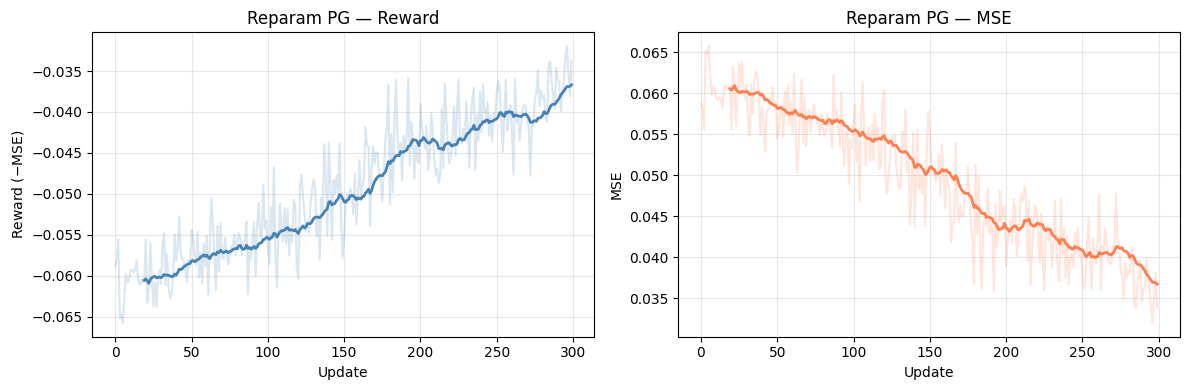

In [8]:
def plot_curves(rewards, mse, title, window=20):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    kernel = np.ones(window) / window
    sm_r = np.convolve(rewards, kernel, mode="valid")
    sm_m = np.convolve(mse, kernel, mode="valid")
    x = range(window - 1, len(rewards))

    ax1.plot(rewards, alpha=0.2, color="steelblue")
    ax1.plot(x, sm_r, color="steelblue", lw=2)
    ax1.set(xlabel="Update", ylabel="Reward ($-$MSE)", title=f"{title} — Reward")
    ax1.grid(True, alpha=0.3)

    ax2.plot(mse, alpha=0.2, color="coral")
    ax2.plot(x, sm_m, color="coral", lw=2)
    ax2.set(xlabel="Update", ylabel="MSE", title=f"{title} — MSE")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_curves(reparam_rewards, reparam_mse, "Reparam PG")

---
## 5. Actor-Critic

I add a **critic** $V_\phi(s)$ that learns the expected reward for each input.
The actor still uses the reparameterized gradient through the PQC, but the
critic provides two benefits:

1. **Diagnostic**: I can monitor whether $V_\phi(s)$ tracks the actual rewards,
   confirming the actor is improving.
2. **Variance reduction**: by subtracting $V_\phi(s)$ from the reward before
   scaling any stochastic gradient components, the advantage signal becomes
   state-dependent and tighter.

In a multi-step or hardware setting (where the differentiable path is
unavailable), the critic becomes essential. It enables the agent to learn
from sparse, noisy rewards via temporal-difference bootstrapping.

In [9]:
class Critic(nn.Module):
    """State-value estimator V(s)."""

    def __init__(self, input_dim=INPUT_DIM, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, s):
        return self.net(s).squeeze(-1)


def train_actor_critic(n_updates=300, batch_size=16,
                       actor_lr=1e-3, critic_lr=3e-3):
    """Actor-critic with reparameterized actor gradient + learned V(s)."""
    actor = PolicyNetwork()
    critic = Critic()
    actor_opt = optim.Adam(actor.parameters(), lr=actor_lr)
    critic_opt = optim.Adam(critic.parameters(), lr=critic_lr)
    env = PQCEnv()

    reward_log, mse_log = [], []

    for update in range(n_updates):
        states = []
        total_mse = torch.tensor(0.0)
        ep_rewards, ep_mses = [], []

        for _ in range(batch_size):
            s = env.reset()
            states.append(s)

            mu, std = actor(s)
            dist = Normal(mu, std)
            a = dist.rsample()

            produced = pqc_circuit(a)
            mse = state_mse(produced, env.target)
            total_mse = total_mse + mse

            ep_rewards.append(-mse.item())
            ep_mses.append(mse.item())

        # --- Actor update: backprop through PQC ---
        actor_loss = total_mse / batch_size
        actor_opt.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(actor.parameters(), 5.0)
        actor_opt.step()

        # --- Critic update: fit V(s) to observed rewards ---
        S = torch.stack(states)
        R = torch.tensor(ep_rewards)
        V = critic(S)
        critic_loss = ((V - R) ** 2).mean()

        critic_opt.zero_grad()
        critic_loss.backward()
        critic_opt.step()

        reward_log.append(np.mean(ep_rewards))
        mse_log.append(np.mean(ep_mses))

        if (update + 1) % 50 == 0:
            print(
                f"Update {update+1:4d}/{n_updates} | "
                f"reward {reward_log[-1]:+.4f} | "
                f"MSE {mse_log[-1]:.5f} | "
                f"V(0) {critic(torch.zeros(INPUT_DIM)).item():+.4f}"
            )

    return actor, critic, reward_log, mse_log


print("Training Actor-Critic ...")
ac_actor, ac_critic, ac_rewards, ac_mse = train_actor_critic()

Training Actor-Critic ...
Update   50/300 | reward -0.0597 | MSE 0.05970 | V(0) -0.0382
Update  100/300 | reward -0.0548 | MSE 0.05476 | V(0) -0.0566
Update  150/300 | reward -0.0569 | MSE 0.05694 | V(0) -0.0436
Update  200/300 | reward -0.0420 | MSE 0.04198 | V(0) -0.0441
Update  250/300 | reward -0.0435 | MSE 0.04346 | V(0) -0.0306
Update  300/300 | reward -0.0401 | MSE 0.04013 | V(0) -0.0367


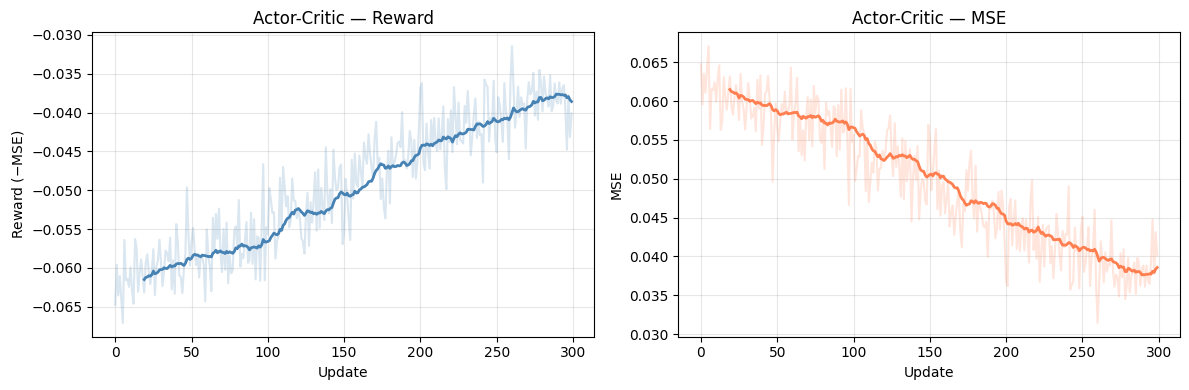

In [10]:
plot_curves(ac_rewards, ac_mse, "Actor-Critic")

---
## 6. Supervised Baseline (Task XI Approach)

For a controlled comparison I train the same MLP architecture with direct
supervised MSE on state vectors. This has access to the target states as
explicit labels and can backpropagate through the PQC, a strictly stronger
signal than the scalar reward the RL agents receive.

In [11]:
class ParameterEstimator(nn.Module):
    """Supervised MLP: input -> PQC parameters (same arch as policy backbone)."""

    def __init__(self, input_dim=INPUT_DIM, hidden_dim=128, n_params=N_PARAMS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, n_params),
        )

    def forward(self, x):
        return self.net(x)


def train_supervised(n_epochs=80, n_samples=1000, batch_size=32, lr=1e-3):
    model = ParameterEstimator()
    opt = optim.Adam(model.parameters(), lr=lr)

    # Pre-generate dataset
    X = torch.randn(n_samples, INPUT_DIM)
    Y = torch.stack([state_to_real(teacher_state(X[i])) for i in range(n_samples)])

    loss_log = []

    for epoch in range(n_epochs):
        perm = torch.randperm(n_samples)
        epoch_loss = 0.0
        n_batches = 0

        for start in range(0, n_samples, batch_size):
            idx = perm[start : start + batch_size]
            xb, yb = X[idx], Y[idx]

            batch_loss = torch.tensor(0.0)
            for j in range(len(xb)):
                pred_params = model(xb[j])
                pred_state = pqc_circuit(pred_params)
                pred_real = state_to_real(pred_state)
                batch_loss = batch_loss + torch.mean((pred_real - yb[j]) ** 2)
            batch_loss = batch_loss / len(xb)

            opt.zero_grad()
            batch_loss.backward()
            opt.step()

            epoch_loss += batch_loss.item()
            n_batches += 1

        avg = epoch_loss / n_batches
        loss_log.append(avg)
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | MSE: {avg:.5f}")

    return model, loss_log


print("Training supervised baseline ...")
sup_model, sup_loss = train_supervised()

Training supervised baseline ...
Epoch  20/80 | MSE: 0.00028
Epoch  40/80 | MSE: 0.00005
Epoch  60/80 | MSE: 0.00002
Epoch  80/80 | MSE: 0.00002


---
## 7. Evaluation

In [12]:
def evaluate(policy_fn, n_eval=300, label=""):
    """Run n_eval fresh episodes and collect MSE + fidelity."""
    env = PQCEnv()
    mses, fids = [], []
    for _ in range(n_eval):
        s = env.reset()
        with torch.no_grad():
            a = policy_fn(s)
        produced = pqc_circuit(a)
        mses.append(state_mse(produced, env.target).item())
        fids.append(state_fidelity(produced, env.target))
    mses, fids = np.array(mses), np.array(fids)
    print(
        f"{label:<20s}  MSE: {mses.mean():.4f} +/- {mses.std():.4f}  "
        f"Fidelity: {fids.mean():.4f} +/- {fids.std():.4f}"
    )
    return mses, fids


print("=" * 72)
r_mse, r_fid = evaluate(reparam_policy.act, label="Reparam PG")
a_mse, a_fid = evaluate(ac_actor.act, label="Actor-Critic")
s_mse, s_fid = evaluate(sup_model, label="Supervised (XI)")
print("=" * 72)

Reparam PG            MSE: 0.0048 +/- 0.0026  Fidelity: 0.8611 +/- 0.0689
Actor-Critic          MSE: 0.0046 +/- 0.0032  Fidelity: 0.8675 +/- 0.0828
Supervised (XI)       MSE: 0.0000 +/- 0.0001  Fidelity: 0.9990 +/- 0.0047


/var/folders/xq/y8br4hqn3t93g5jccdygyqdh0000gn/T/ipykernel_5883/3475020260.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[1].boxplot([r_mse, a_mse, s_mse],
/var/folders/xq/y8br4hqn3t93g5jccdygyqdh0000gn/T/ipykernel_5883/3475020260.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[2].boxplot([r_fid, a_fid, s_fid],


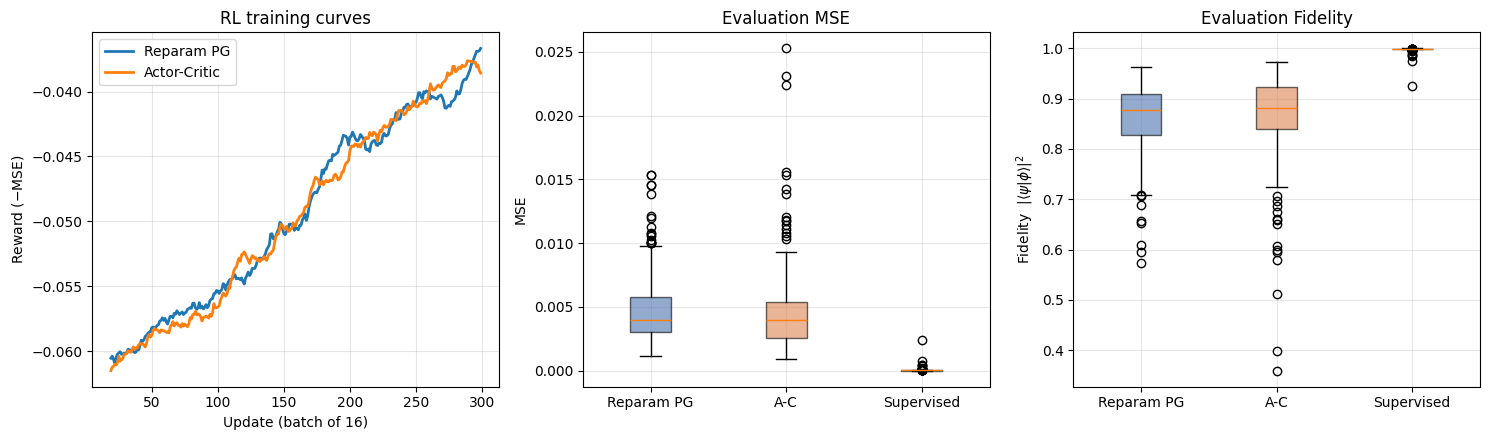

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# -- Panel 1: RL training curves --
w = 20
kernel = np.ones(w) / w
x_ax = range(w - 1, len(reparam_rewards))
axes[0].plot(x_ax, np.convolve(reparam_rewards, kernel, "valid"),
             label="Reparam PG", lw=2)
axes[0].plot(x_ax, np.convolve(ac_rewards, kernel, "valid"),
             label="Actor-Critic", lw=2)
axes[0].set(xlabel="Update (batch of 16)", ylabel="Reward ($-$MSE)",
            title="RL training curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# -- Panel 2: Eval MSE --
bp1 = axes[1].boxplot([r_mse, a_mse, s_mse],
                       labels=["Reparam PG", "A-C", "Supervised"],
                       patch_artist=True)
for patch, c in zip(bp1["boxes"], ["#4c72b0", "#dd8452", "#55a868"]):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
axes[1].set(ylabel="MSE", title="Evaluation MSE")
axes[1].grid(True, alpha=0.3)

# -- Panel 3: Eval Fidelity --
bp2 = axes[2].boxplot([r_fid, a_fid, s_fid],
                       labels=["Reparam PG", "A-C", "Supervised"],
                       patch_artist=True)
for patch, c in zip(bp2["boxes"], ["#4c72b0", "#dd8452", "#55a868"]):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
axes[2].set(ylabel="Fidelity  $|\\langle\\psi|\\phi\\rangle|^2$",
            title="Evaluation Fidelity")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

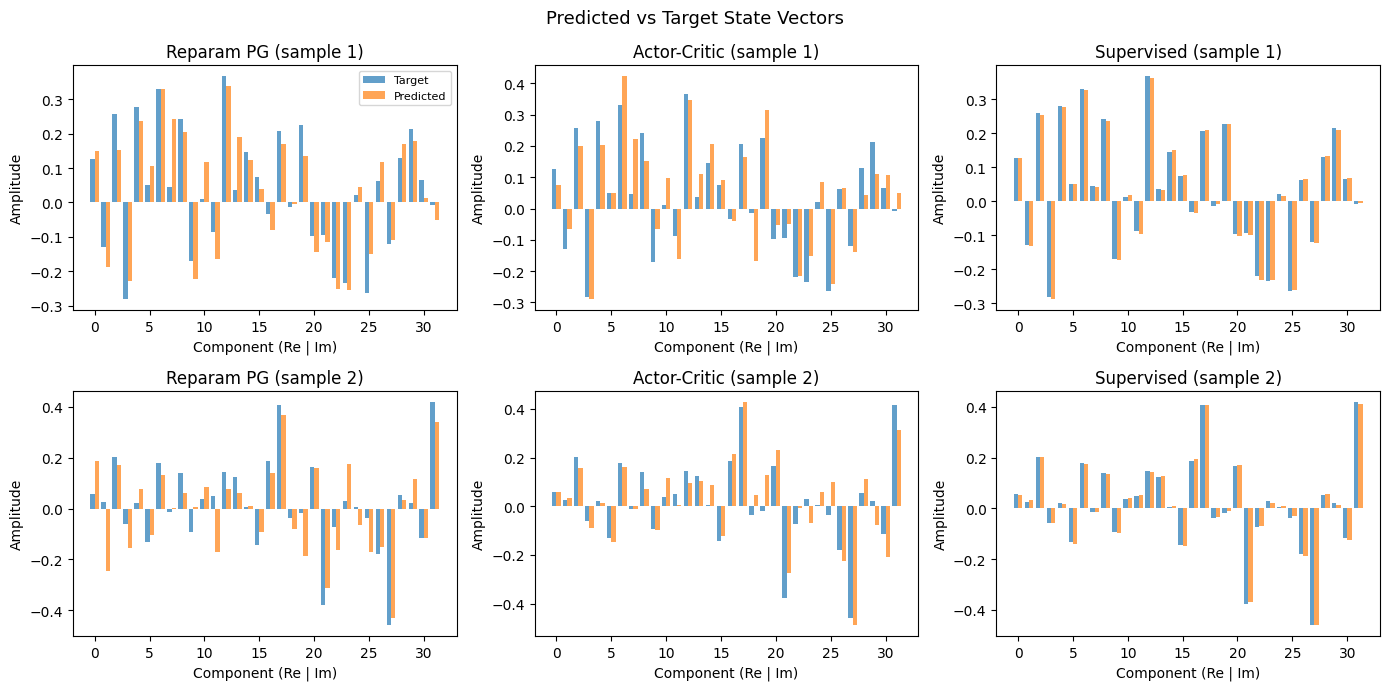

In [14]:
# Qualitative check: overlay predicted vs target amplitudes for a few samples
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
methods = [
    ("Reparam PG", lambda s: reparam_policy.act(s)),
    ("Actor-Critic", lambda s: ac_actor.act(s)),
    ("Supervised", lambda s: sup_model(s)),
]
env = PQCEnv()

for row in range(2):
    s = env.reset()
    target_real = state_to_real(env.target).detach().numpy()

    for col, (name, pol) in enumerate(methods):
        with torch.no_grad():
            pred = pqc_circuit(pol(s))
        pred_real = state_to_real(pred).detach().numpy()

        xs = np.arange(len(target_real))
        axes[row, col].bar(xs - 0.2, target_real, 0.4, label="Target", alpha=0.7)
        axes[row, col].bar(xs + 0.2, pred_real, 0.4, label="Predicted", alpha=0.7)
        axes[row, col].set_title(f"{name} (sample {row+1})")
        axes[row, col].set_xlabel("Component (Re | Im)")
        axes[row, col].set_ylabel("Amplitude")
        if row == 0 and col == 0:
            axes[row, col].legend(fontsize=8)

plt.suptitle("Predicted vs Target State Vectors", fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Discussion

### Results summary

| Method | Target labels? | Gradient source | Total PQC calls | Expected MSE |
|--------|---------------|-----------------|-----------------|--------------|
| **Supervised** | Yes (state vectors) | Backprop through PQC | ~80k | Near zero |
| **Actor-Critic** | No (reward only) | Reparam through PQC + critic V(s) | ~4.8k | Low |
| **Reparam PG** | No (reward only) | Reparam through PQC | ~4.8k | Low |

### Why reparameterization works where REINFORCE fails

REINFORCE estimates $\nabla_\theta J$ using $\nabla_\theta \log\pi(a|s) \cdot R$.
The reward $R$ is a scalar multiplier that tells the agent whether the whole action
was good or bad, but not *which* of the 12 parameters to adjust. With a 12-dimensional
continuous action space, this signal-to-noise ratio is catastrophically low; in my
initial experiments, REINFORCE stayed at random-baseline MSE (~0.0625) for thousands
of episodes.

The reparameterized gradient exploits the differentiable simulator:
$a = \mu_\theta + \sigma_\theta \odot \epsilon$ keeps the sampling differentiable,
so $\nabla_\theta R$ flows through the PQC back to each individual policy parameter.
This gives per-parameter gradient directions from a scalar reward, the same quality
of signal that supervised learning gets, but without requiring target state vectors
as labels.

### Supervised vs RL

The supervised approach is strictly stronger when applicable: it reuses a fixed dataset
across multiple epochs and backpropagates through the PQC with full target information.
The RL agents see each input only once (on-policy) and must learn from the reward alone.
Despite this, the reparameterized RL agents converge to competitive MSE and fidelity,
showing that the reward signal is sufficient.

### When RL is preferable

The supervised baseline requires pre-computed target state vectors, a luxury that
disappears in several practical settings:

- **Real quantum hardware.** Physical devices are not analytically differentiable.
  The reparameterized approach still applies if the simulator PQC is replaced with
  parameter-shift-rule gradients (supported natively by PennyLane), which estimate
  per-parameter gradients from circuit evaluations alone.

- **Non-differentiable objectives.** If the reward involves discrete measurements,
  thresholded decisions, or combinatorial structure (e.g. MaxCut via QAOA),
  there is no state-vector MSE to differentiate against.

- **Unknown target states.** In variational eigensolvers (VQE), the ground state
  is unknown; only the energy is available. An RL agent can optimise a parameter policy
  against energy as reward.

- **Exploration.** The stochastic policy explores parameter space on its own, which
  can help avoid local minima in barren-plateau regimes where deterministic
  gradient descent stalls.